In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

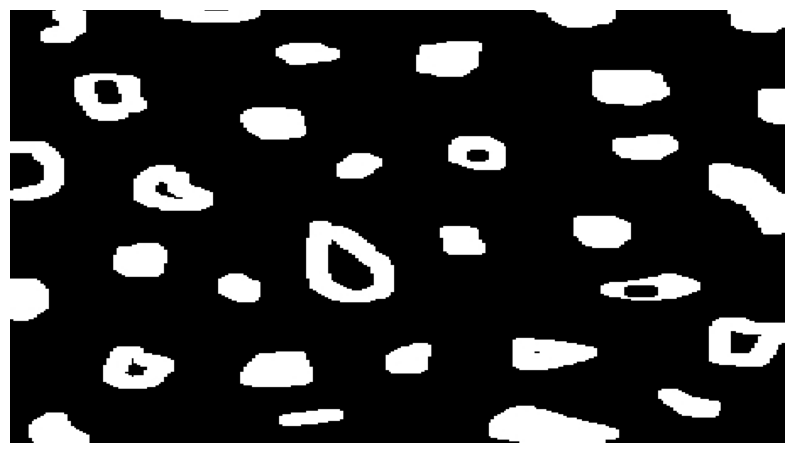

In [2]:
img = cv2.imread("../images/result_bubbles_original.png(1).jpeg")
plt.figure(figsize=(10,10))
plt.imshow(img[...,::-1]);plt.axis('off');

Text(0.5, 1.0, 'full red ')

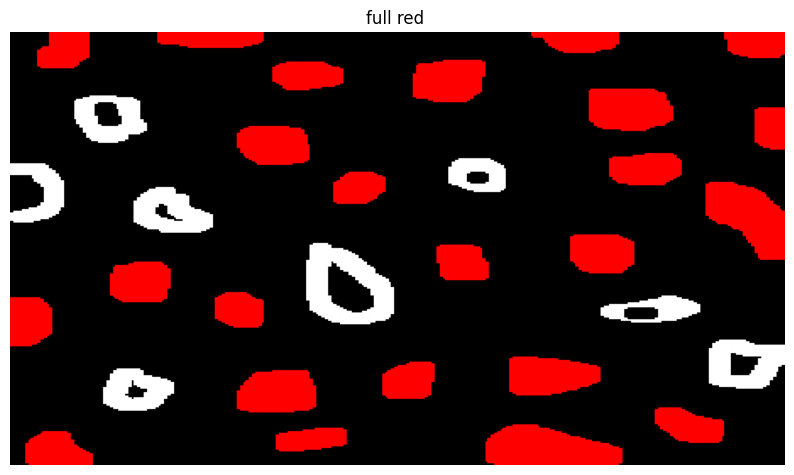

In [3]:
img_copy = img.copy()
img_gray = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)
img_blur = cv2.GaussianBlur(img_gray, (5,5), 0)
contours, hierarchy = cv2.findContours(img_blur, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

fulls = img_copy.copy()
full_contours = []
if hierarchy is not None:
    hierarchy = hierarchy[0]
    for i, c in enumerate(contours):
        M = cv2.moments(c)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            if hierarchy[i][2] == -1:
                if img_blur[cy, cx] > 127: 
                    full_contours.append(c)
                    cv2.circle(fulls, (cx, cy), 2, (0, 0, 255), -1)
    
plt.figure(figsize=(10,10))
draw_full = cv2.drawContours(img_copy.copy(), full_contours, -1, (0,0 ,255), cv2.FILLED)
plt.imshow(draw_full[...,::-1]); plt.axis('off'); plt.title("full red ")